<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Superconductivity_Record_Timeline_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)


# Superconducting critical temperature record timeline

This notebook plots selected record breaking superconducting transition temperatures and places a dry ice reference at 194.65 K, equivalent to −78.5 °C at approximately one atmosphere.

Ambient pressure records and sustained high pressure records appear as separate curves. Withdrawn submissions and the provisional preprint for the 2025 LaSc₂H₂₄ study are displayed as distinct indicators and are excluded from the endorsed data curves.

In [ ]:
!uv pip install matplotlib numpy pandas ipython adjustText

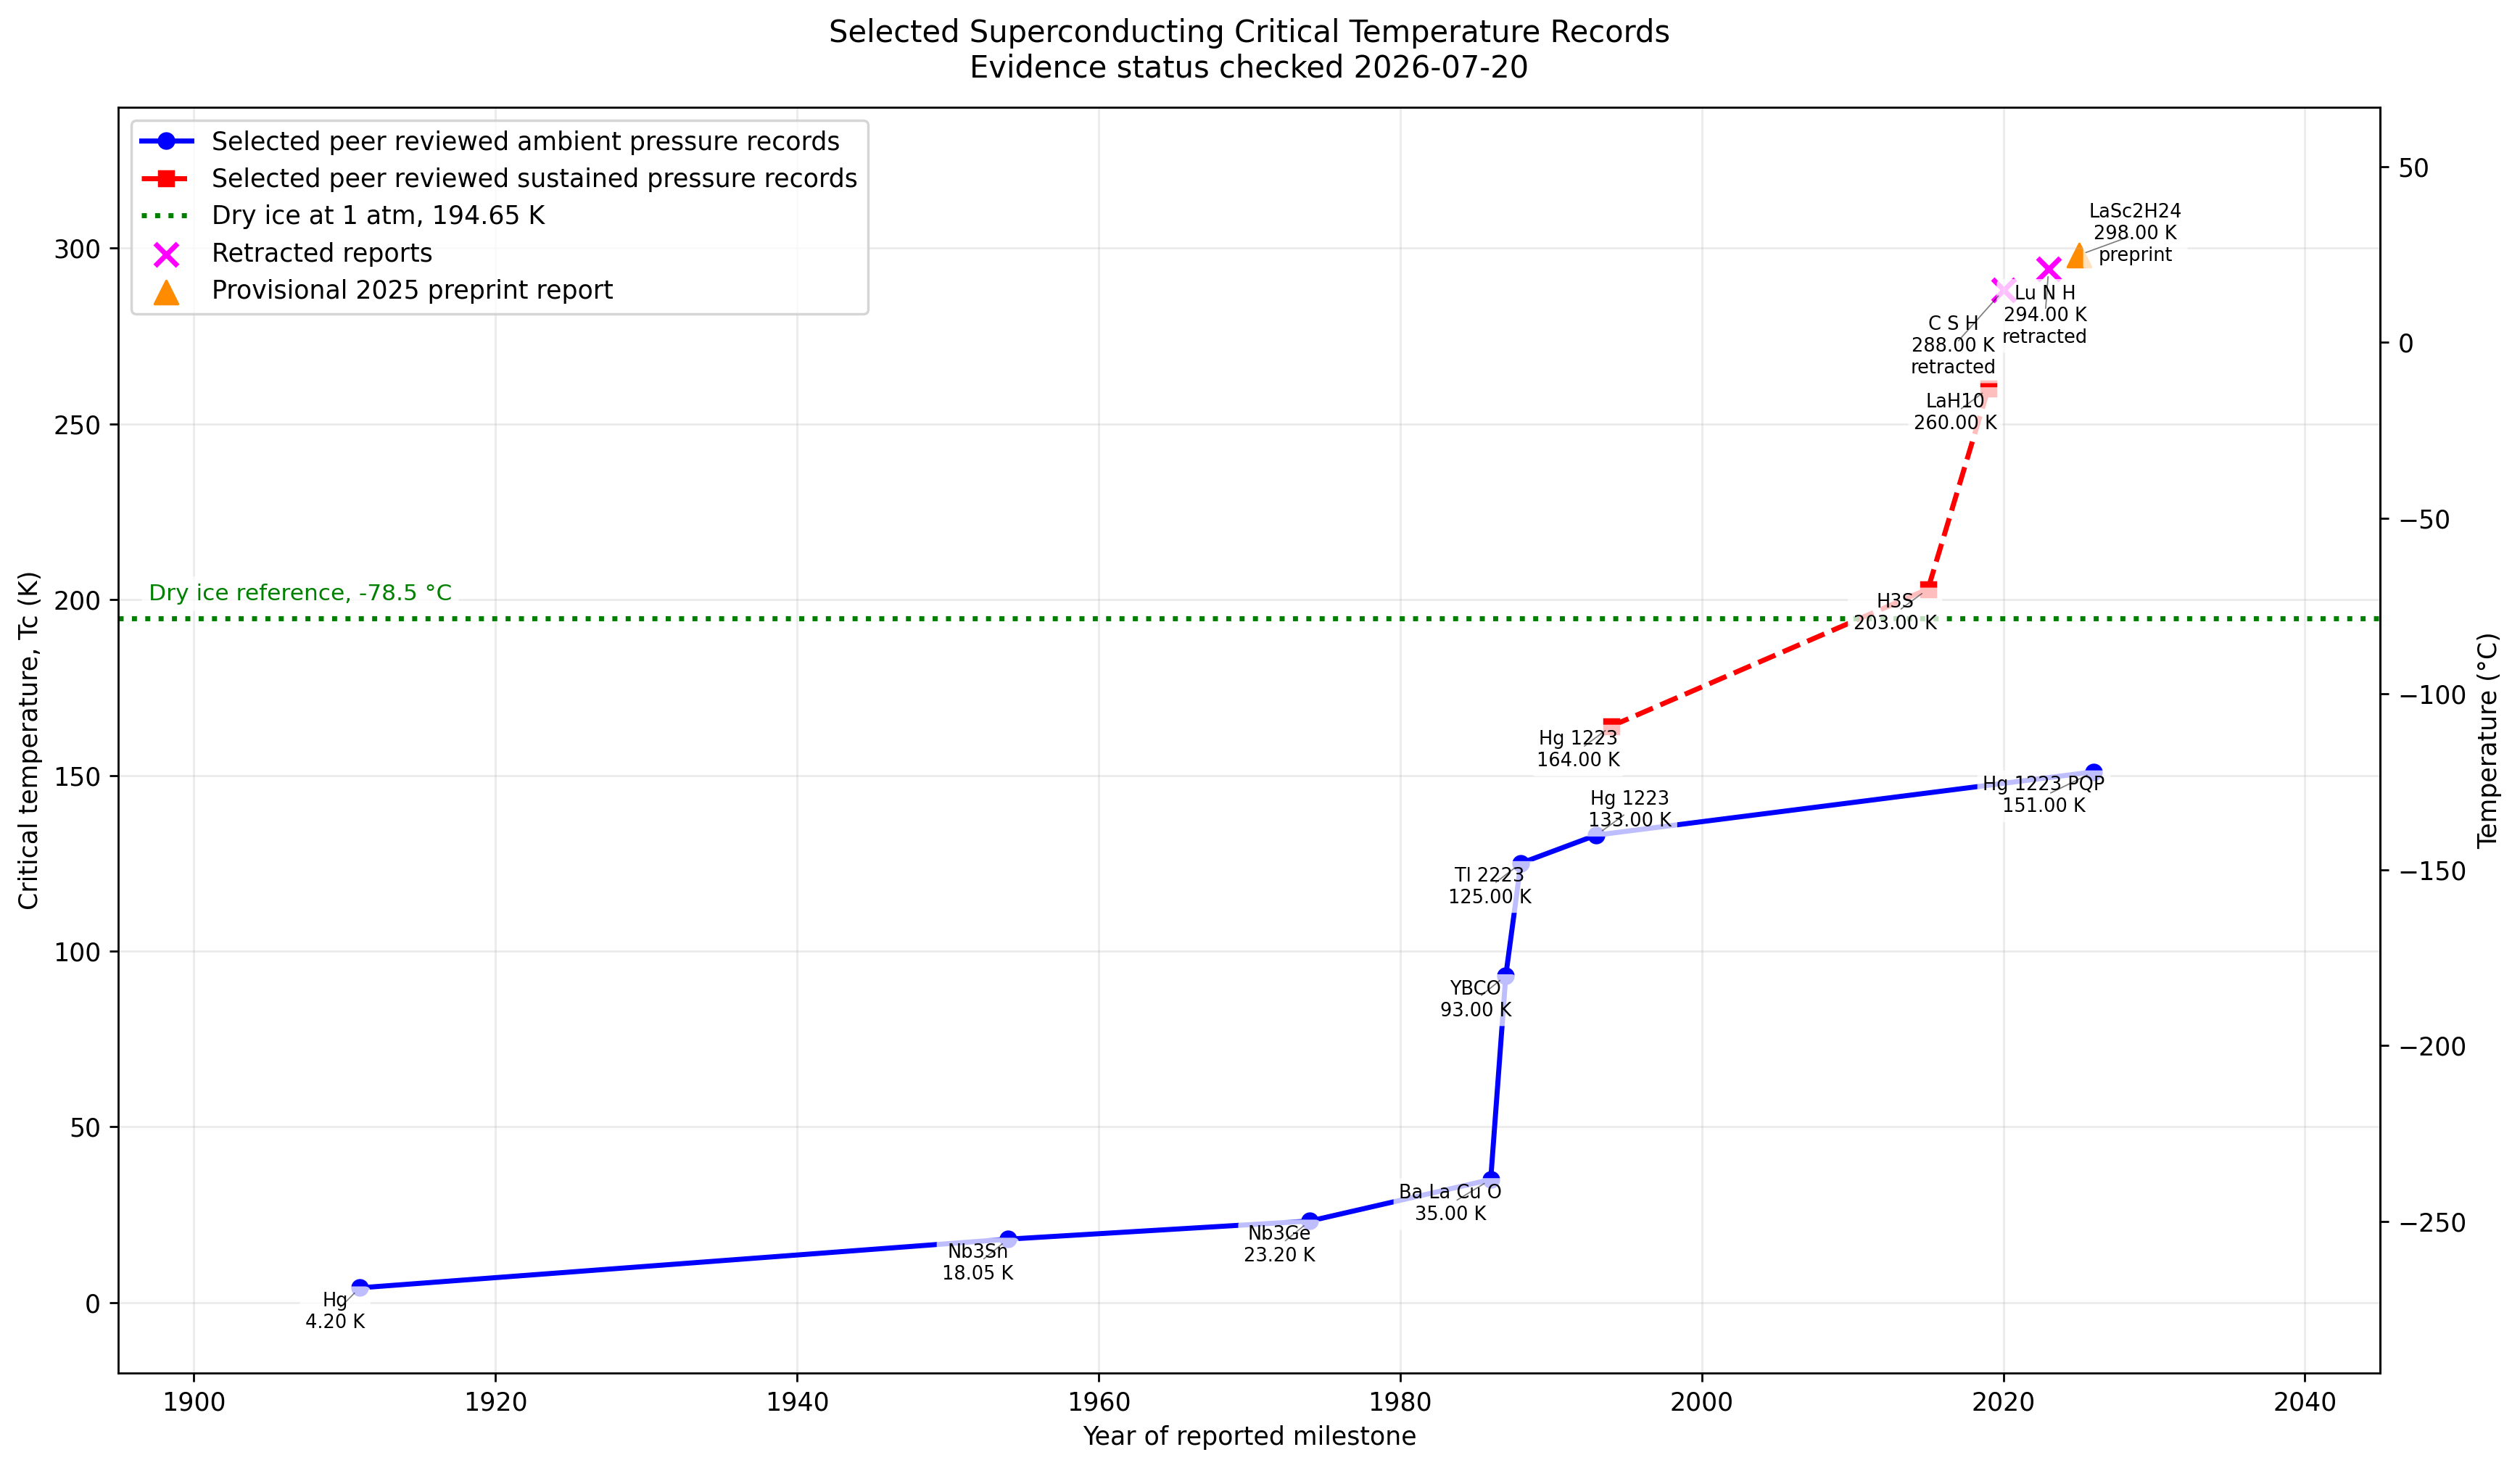

,reference,temperature_k,temperature_c,offset_from_dry_ice_k
0,Dry ice at 1 atm,194.65,-78.50,0.00
1,"2026 ambient record, Hg 1223 PQP",151.00,-122.15,-43.65
2,"2015 sustained pressure record, H3S",203.00,-70.15,8.35
3,"2019 sustained pressure record, LaH10",260.00,-13.15,65.35
4,"2025 provisional preprint, LaSc2H24",298.00,24.85,103.35


In [12]:
"""This script plots selected superconducting critical temperature records."""

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text
from IPython.display import display

# Control knobs
DATA_CUTOFF_DATE = "2026-07-20"
DRY_ICE_K = 194.65
SHOW_RETRACTED_REPORTS = True
SHOW_PROVISIONAL_REPORT = True
SHOW_CELSIUS_AXIS = True
LABEL_POINTS = True
TRANSPARENT_BACKGROUND = True
FIGURE_SIZE = (14.0, 8.2)
Y_LIMITS_K = (-20.0, 340.0)
X_LIMITS_YEAR = (1895, 2045)

# Color control knobs for high contrast
COLOR_AMBIENT = "#0000FF"
COLOR_HIGH_PRESSURE = "#FF0000"
COLOR_DRY_ICE = "#008000"
COLOR_RETRACTED = "#FF00FF"
COLOR_PROVISIONAL = "#FF8C00"

# Visualization settings
plt.rcParams["figure.dpi"] = 250
plt.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
plt.rcParams["font.weight"] = "normal"
plt.rcParams["axes.titlepad"] = 12.0

ambient_records = pd.DataFrame(
    [
        (
            1911,
            4.20,
            "Hg",
            "Mercury",
            "Ambient",
            "Peer reviewed",
            "Kamerlingh Onnes, Leiden Communications 120b and 122b",
        ),
        (
            1954,
            18.05,
            "Nb3Sn",
            "Niobium tin",
            "Ambient",
            "Peer reviewed",
            "Matthias et al., Physical Review 95, 1435",
        ),
        (
            1974,
            23.20,
            "Nb3Ge",
            "Niobium germanium",
            "Ambient",
            "Peer reviewed",
            "Testardi et al., Solid State Communications 15, 1",
        ),
        (
            1986,
            35.00,
            "Ba La Cu O",
            "Barium lanthanum copper oxide",
            "Ambient",
            "Peer reviewed",
            "Bednorz and Muller, Zeitschrift fur Physik B 64, 189",
        ),
        (
            1987,
            93.00,
            "YBCO",
            "Yttrium barium copper oxide",
            "Ambient",
            "Peer reviewed",
            "Wu et al., Physical Review Letters 58, 908",
        ),
        (
            1988,
            125.00,
            "Tl 2223",
            "Tl2Ba2Ca2Cu3O10",
            "Ambient",
            "Peer reviewed",
            "Parkin et al., Physical Review Letters 60, 2539",
        ),
        (
            1993,
            133.00,
            "Hg 1223",
            "HgBa2Ca2Cu3O8+d",
            "Ambient",
            "Peer reviewed",
            "Schilling et al., Nature 363, 56",
        ),
        (
            2026,
            151.00,
            "Hg 1223 PQP",
            "Pressure quenched HgBa2Ca2Cu3O8+d",
            "Measured at ambient pressure",
            "Peer reviewed",
            "Deng et al., PNAS 123, e2536178123",
        ),
    ],
    columns=[
        "year",
        "tc_k",
        "plot_label",
        "material",
        "pressure",
        "evidence",
        "source",
    ],
)

high_pressure_records = pd.DataFrame(
    [
        (
            1994,
            164.0,
            "Hg 1223",
            "HgBa2Ca2Cu3O8+d",
            "Quasihydrostatic pressure",
            "Peer reviewed",
            "Gao et al., Physical Review B 50, 4260",
        ),
        (
            2015,
            203.0,
            "H3S",
            "Sulfur hydride system, H3S rich phase",
            "About 155 GPa",
            "Peer reviewed",
            "Drozdov et al., Nature 525, 73",
        ),
        (
            2019,
            260.0,
            "LaH10",
            "Lanthanum superhydride",
            "About 180 to 200 GPa",
            "Peer reviewed",
            "Somayazulu et al., Physical Review Letters 122, 027001",
        ),
    ],
    columns=[
        "year",
        "tc_k",
        "plot_label",
        "material",
        "pressure",
        "evidence",
        "source",
    ],
)

retracted_reports = pd.DataFrame(
    [
        (
            2020,
            288.0,
            "C S H",
            "Carbonaceous sulfur hydride",
            "About 267 GPa",
            "Retracted",
            "Nature retraction published in 2022",
        ),
        (
            2023,
            294.0,
            "Lu N H",
            "Nitrogen doped lutetium hydride",
            "About 1 GPa",
            "Retracted",
            "Nature retraction published in 2023",
        ),
    ],
    columns=[
        "year",
        "tc_k",
        "plot_label",
        "material",
        "pressure",
        "evidence",
        "source",
    ],
)

provisional_report = pd.DataFrame(
    [
        (
            2025,
            298.0,
            "LaSc2H24",
            "Lanthanum scandium hydride",
            "About 195 to 266 GPa",
            "2025 preprint, provisional",
            "Song et al., arXiv:2510.01273",
        ),
    ],
    columns=[
        "year",
        "tc_k",
        "plot_label",
        "material",
        "pressure",
        "evidence",
        "source",
    ],
)


def kelvin_to_celsius(
    temperature_k: float | np.ndarray,
) -> np.ndarray:
    """Convert temperature from kelvin to degrees Celsius.

    Args:
        temperature_k: Temperature value or array in kelvin.

    Returns:
        Temperature array in degrees Celsius.
    """
    return np.asarray(temperature_k) - 273.15


def celsius_to_kelvin(
    temperature_c: float | np.ndarray,
) -> np.ndarray:
    """Convert temperature from degrees Celsius to kelvin.

    Args:
        temperature_c: Temperature value or array in degrees Celsius.

    Returns:
        Temperature array in kelvin.
    """
    return np.asarray(temperature_c) + 273.15


def create_point_label(
    axis: Any,
    row: Any,
    suffix: str = "",
) -> Any:
    """Generate one material and temperature text object for programmatic adjustment.

    Args:
        axis: Matplotlib axis receiving the label.
        row: Record with year, tc_k, and plot_label values.
        suffix: Optional evidence text placed below the temperature.

    Returns:
        A Matplotlib text instance.
    """
    label_text = f"{row.plot_label}\n{row.tc_k:.2f} K"
    if suffix:
        label_text = f"{label_text}\n{suffix}"

    return axis.text(
        row.year,
        row.tc_k,
        label_text,
        ha="center",
        va="center",
        fontsize=7.4,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
        ),
    )


fig, ax = plt.subplots(figsize=FIGURE_SIZE)

if TRANSPARENT_BACKGROUND:
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
else:
    fig.patch.set_facecolor("white")
    ax.patch.set_facecolor("white")

ax.plot(
    ambient_records["year"],
    ambient_records["tc_k"],
    marker="o",
    color=COLOR_AMBIENT,
    linewidth=2.0,
    label="Selected peer reviewed ambient pressure records",
)

ax.plot(
    high_pressure_records["year"],
    high_pressure_records["tc_k"],
    marker="s",
    linestyle="--",
    color=COLOR_HIGH_PRESSURE,
    linewidth=2.0,
    label="Selected peer reviewed sustained pressure records",
)

ax.axhline(
    DRY_ICE_K,
    linestyle=":",
    color=COLOR_DRY_ICE,
    linewidth=2.0,
    label=f"Dry ice at 1 atm, {DRY_ICE_K:.2f} K",
)

if SHOW_RETRACTED_REPORTS:
    ax.scatter(
        retracted_reports["year"],
        retracted_reports["tc_k"],
        marker="x",
        color=COLOR_RETRACTED,
        s=80,
        linewidths=2.0,
        label="Retracted reports",
    )

if SHOW_PROVISIONAL_REPORT:
    ax.scatter(
        provisional_report["year"],
        provisional_report["tc_k"],
        marker="^",
        color=COLOR_PROVISIONAL,
        s=85,
        label="Provisional 2025 preprint report",
    )

if LABEL_POINTS:
    plotted_texts = []

    for row in ambient_records.itertuples(index=False):
        plotted_texts.append(create_point_label(ax, row))

    for row in high_pressure_records.itertuples(index=False):
        plotted_texts.append(create_point_label(ax, row))

    if SHOW_RETRACTED_REPORTS:
        for row in retracted_reports.itertuples(index=False):
            plotted_texts.append(create_point_label(ax, row, "retracted"))

    if SHOW_PROVISIONAL_REPORT:
        for row in provisional_report.itertuples(index=False):
            plotted_texts.append(create_point_label(ax, row, "preprint"))

    adjust_text(
        plotted_texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.5,
            shrinkA=3.0,
            shrinkB=3.0
        ),
        expand_points=(2.5, 2.5),
        expand_text=(1.5, 1.5),
        force_points=(1.2, 1.2),
        force_text=(1.0, 1.0),
    )

ax.text(
    X_LIMITS_YEAR[0] + 2,
    DRY_ICE_K + 4,
    "Dry ice reference, -78.5 °C",
    fontsize=9,
    va="bottom",
    color=COLOR_DRY_ICE,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="none",
        alpha=0.75,
    ),
)

ax.set_title(
    "Selected Superconducting Critical Temperature Records\n"
    f"Evidence status checked {DATA_CUTOFF_DATE}"
)
ax.set_xlabel("Year of reported milestone")
ax.set_ylabel("Critical temperature, Tc (K)")
ax.set_xlim(*X_LIMITS_YEAR)
ax.set_ylim(*Y_LIMITS_K)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", frameon=True)

if SHOW_CELSIUS_AXIS:
    secondary_axis = ax.secondary_yaxis(
        "right",
        functions=(kelvin_to_celsius, celsius_to_kelvin),
    )
    secondary_axis.set_ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

comparison_table = pd.DataFrame(
    [
        ("Dry ice at 1 atm", DRY_ICE_K),
        ("2026 ambient record, Hg 1223 PQP", 151.0),
        ("2015 sustained pressure record, H3S", 203.0),
        ("2019 sustained pressure record, LaH10", 260.0),
        ("2025 provisional preprint, LaSc2H24", 298.0),
    ],
    columns=["reference", "temperature_k"],
)
comparison_table["temperature_c"] = (
    comparison_table["temperature_k"] - 273.15
)
comparison_table["offset_from_dry_ice_k"] = (
    comparison_table["temperature_k"] - DRY_ICE_K
)
display(comparison_table.round(2))

record_table = pd.concat(
    [
        ambient_records.assign(record_class="Ambient record"),
        high_pressure_records.assign(record_class="Sustained pressure record"),
        retracted_reports.assign(record_class="Retracted report"),
        provisional_report.assign(record_class="Provisional report"),
    ],
    ignore_index=True,
)
record_table["temperature_c"] = record_table["tc_k"] - 273.15
record_table["offset_from_dry_ice_k"] = (
    record_table["tc_k"] - DRY_ICE_K
)

The 2026 pressure quench result reaches 151 K at ambient pressure, which is 43.65 K colder than dry ice. The 2015 H₃S result reaches 203 K under about 155 GPa, which is 8.35 K warmer than dry ice. The 2019 lanthanum superhydride result reaches the reported 260 K frontier under about 180 to 200 GPa, which is 65.35 K warmer than dry ice.

The 2025 LaSc₂H₂₄ preprint reports a 298 K onset under extreme pressure. A May 2026 preprint describes unsuccessful synthesis attempts and an absence of superconductivity from 245 to 300 K in the resulting La Sc H products. The chart therefore places 298 K in the provisional evidence class.



## Verification sources

1. Deng et al., *Ambient pressure 151 K superconductivity in
   HgBa₂Ca₂Cu₃O₈+δ via pressure quench*, PNAS 123, e2536178123 (2026).
   https://www.pnas.org/doi/10.1073/pnas.2536178123

2. Drozdov et al., *Conventional superconductivity at 203 kelvin at high
   pressures in the sulfur hydride system*, Nature 525, 73 (2015).
   https://www.nature.com/articles/nature14964

3. Somayazulu et al., *Evidence for Superconductivity above 260 K in
   Lanthanum Superhydride at Megabar Pressures*, Physical Review Letters
   122, 027001 (2019).
   https://link.aps.org/doi/10.1103/PhysRevLett.122.027001

4. Gao et al., *Superconductivity up to 164 K in mercury cuprates under
   quasihydrostatic pressures*, Physical Review B 50, 4260 (1994).
   https://link.aps.org/doi/10.1103/PhysRevB.50.4260

5. Schilling et al., *Superconductivity above 130 K in the
   Hg Ba Ca Cu O system*, Nature 363, 56 (1993).
   https://www.nature.com/articles/363056a0

6. Wu et al., *Superconductivity at 93 K in a new mixed phase
   Y Ba Cu O compound system at ambient pressure*, Physical Review Letters
   58, 908 (1987).
   https://link.aps.org/doi/10.1103/PhysRevLett.58.908

7. Nature retraction for the 2020 carbonaceous sulfur hydride claim.
   https://www.nature.com/articles/s41586-022-05294-9

8. Nature retraction for the 2023 nitrogen doped lutetium hydride claim.
   https://www.nature.com/articles/s41586-023-06774-2

9. Song et al., 298 K LaSc₂H₂₄ preprint, arXiv:2510.01273 (2025).
   https://arxiv.org/abs/2510.01273

10. Semenok et al., experimental reproducibility study,
    arXiv:2605.29985 (2026).
    https://arxiv.org/abs/2605.29985

11. CDC dry ice temperature reference.
    https://www.cdc.gov/mmwr/preview/mmwrhtml/mm5350a6.htm
